# Do MD-match analysis on a SHARC ensemble

Set `SHARC_PATH` to the SHARC ensemble root folder, set `COMPARISON_PATH` to the folder containing the comparison data, set min and max thresholds, then Run All

In [39]:
# Input information

from pathlib import Path
import matplotlib.pyplot as plt
import sys
import numpy as np

repository_path = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "sharc_scripts" / "tools" / "parse_sharc_output.py").is_file()
)
sys.path[:0] = [str(repository_path)]
from sharc_scripts.tools.parse_sharc_output import read_sharc_ensemble
from sharc_scripts.tools.md_match.parse_comparison import read_comparison_ensemble
from sharc_scripts.tools.md_match.cumulative_error import calculate_ensemble_cumulative_error
from sharc_scripts.tools.md_match.match_duration import calculate_ensemble_match_duration

COMPARISON_PATH = Path('/home/lim_yt/X-MACE-sampling/sharc/A01_FromEqui')
SHARC_PATH = Path('/home/lim_yt/X-MACE-sampling/sharc/ethene_02_dynamic_first_from_equi')

# errors below these thresholds will be ignored
min_energy_error = 0.04
min_force_error = 0.04
min_nac_error = None # set to None to ignore NACs

# when cumulative errors reach any of these thresholds, the MD match is considered failed
max_energy_error = 1
max_force_error = 1
max_nac_error = None # set to None to ignore NACs


In [40]:
# Parse ensembles

sharc = read_sharc_ensemble(SHARC_PATH)
comparison = read_comparison_ensemble(COMPARISON_PATH)

sharc_length = len(sharc.trajectories)
comparison_length = len(comparison.trajectories)
common_length = min(sharc_length, comparison_length)
print(f'SHARC trajectories: {sharc_length}')
print(f'Comparison trajectories: {comparison_length}')
print(f'Analysis will proceed up to the shorter length: {common_length} trajectories')


SHARC trajectories: 100
Comparison trajectories: 100
Analysis will proceed up to the shorter length: 100 trajectories


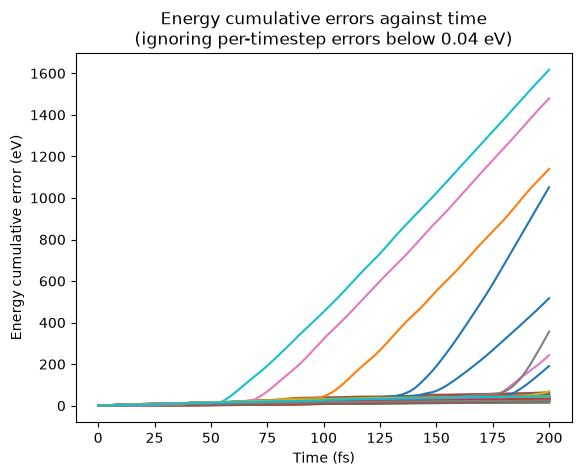

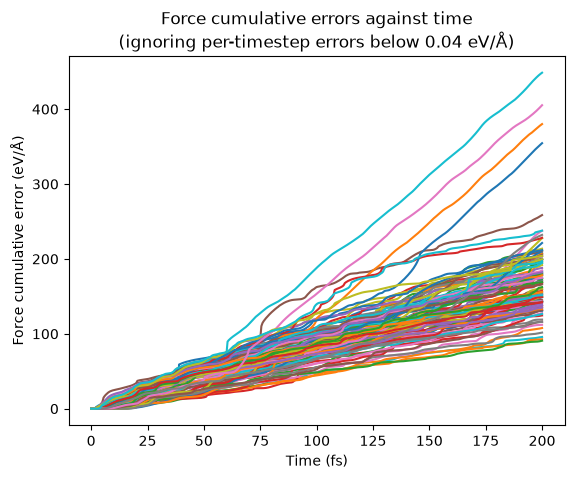

In [41]:
# Calculate and plot cumulative errors

errors = calculate_ensemble_cumulative_error(
    sharc, comparison, min_energy_error, min_force_error, min_nac_error
)

plt.figure()
for result in errors.values():
    plt.plot(result['time'], result['energy_cumulative_error'])
plt.title(f'Energy cumulative errors against time\n(ignoring per-timestep errors below {min_energy_error} eV)')
plt.xlabel('Time (fs)')
plt.ylabel('Energy cumulative error (eV)')
plt.show()

plt.figure()
for result in errors.values():
    plt.plot(result['time'], result['forces_cumulative_error'])
plt.title(f'Force cumulative errors against time\n(ignoring per-timestep errors below {min_force_error} eV/Å)')
plt.xlabel('Time (fs)')
plt.ylabel('Force cumulative error (eV/Å)')
plt.show()

if any(result['nacs_cumulative_error'] is not None for result in errors.values()):
    plt.figure()
    for result in errors.values():
        if result['nacs_cumulative_error'] is not None:
            plt.plot(result['time'], result['nacs_cumulative_error'])
    plt.title(f'NACs cumulative errors against time\n(ignoring per-timestep errors below {min_nac_error} Å^-1)')
    plt.xlabel('Time (fs)')
    plt.ylabel('NACs cumulative error (Å^-1)')
    plt.show()


100 trajectories failed due to exceeding the threshold for forces.


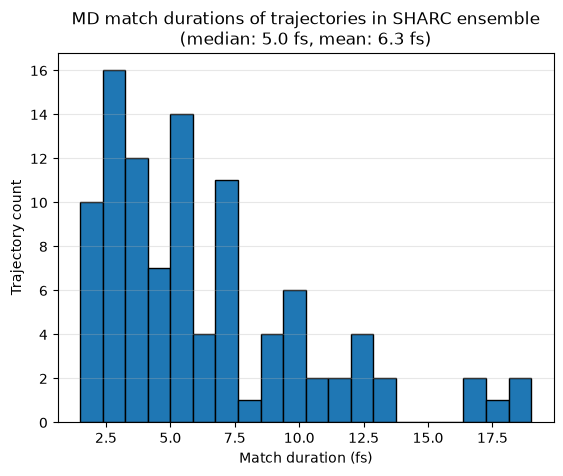

In [42]:
# Calculate and plot match durations

durations = calculate_ensemble_match_duration(
    errors, max_energy_error, max_force_error, max_nac_error
)
median = np.median([result['duration'] for result in durations.values()])
mean = np.mean([result['duration'] for result in durations.values()])

failed_counts = {}
for result in durations.values():
    failed_counts[result['failed_metric']] = failed_counts.get(result['failed_metric'], 0) + 1
for metric in failed_counts:
    print(f'{failed_counts[metric]} trajectories failed due to exceeding the threshold for {metric}.')

plt.figure()
plt.hist([result['duration'] for result in durations.values()], bins=20, edgecolor="black")
plt.grid(axis="y", alpha=0.3)
plt.title(f'MD match durations of trajectories in SHARC ensemble\n'
          f'(median: {median:.1f} fs, mean: {mean:.1f} fs)')
plt.xlabel('Match duration (fs)')
plt.ylabel('Trajectory count')
plt.show()
